# FP32 vs BF16 Training Ablation

Trains the **same** SZ3+model pipeline in FP32 (`cfg.amp=False`) and BF16 mixed precision
(`cfg.amp=True`) with identical seed / params / epochs, so any difference is purely the
training precision. Plots the **per-epoch PSNR curve** for each precision (NYX and WarpX);
the two curves overlapping shows BF16 preserves FP32-level accuracy (Δ within run-to-run
noise). Output: `bf16_vs_fp32_1x2.pdf`.

In [1]:
# ── fp32 vs BF16 ablation: setup ──────────────────────────────────────────────
import os, sys, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch

SZ3_LIB   = "/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so"
PYSZ_PATH = "/home/sam/Data_Compression/SZ3/tools/pysz"
SCRIPTS   = "/home/sam/Halo_Finder/Final_design/base_script"
for p in (PYSZ_PATH, SCRIPTS):
    if p not in sys.path:
        sys.path.append(p)

import importlib, bg_stage
importlib.reload(bg_stage)
from pysz import SZ
from bg_stage import train_bg_only, run_bg_inference, unwrap_bg_model
from experiment import build_bg_only_cfg, estimate_bg_model_param_bytes
from bg_shard import pick_bg_h_under_budget

device    = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
sz_engine = SZ(SZ3_LIB)
SEED, BYTES_PER_PARAM = 17, 2

def set_seed(s=SEED):
    torch.manual_seed(s); np.random.seed(s); random.seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

def compute_psnr(x, xh, dr):
    mse = float(np.mean((np.asarray(x, np.float64) - np.asarray(xh, np.float64)) ** 2))
    return 100.0 if mse == 0 else 20.0 * np.log10(dr) - 10.0 * np.log10(mse)

def bg_h_for_params(budget, shape, n_fields):
    h, _ = pick_bg_h_under_budget(int(budget), shape=shape, n_fields=int(n_fields),
                                  bg_arch="spatial", h_candidates=list(range(3, 256)))
    return int(h)

print("Setup ready |", device)

Setup ready | cuda:0


In [2]:
# ── A/B core: train the same model in fp32 and BF16, capture per-epoch PSNR ────
# Only cfg.amp differs (seed / init / sampling identical), so any gap is purely
# the training precision. A per-epoch evaluator records the PSNR curve.
def run_ab(name, tgt, aux, rel, params=30000, epochs=10, lr=1e-3):
    tgt      = np.asarray(tgt, np.float32)
    aux      = [np.asarray(a, np.float32) for a in aux]
    drange   = float(tgt.max() - tgt.min())
    n_fields = 1 + len(aux)
    bg_h     = bg_h_for_params(params, tgt.shape, n_fields)
    n_params, _ = estimate_bg_model_param_bytes(
        n_fields=n_fields, shape=tgt.shape, bg_arch="spatial", bg_h=bg_h, dtype_bytes=BYTES_PER_PARAM)
    depth, patch = tgt.shape[0], tgt.shape[2]
    b, _  = sz_engine.compress(tgt, 1, 0, float(rel), 0)
    xq    = np.ascontiguousarray(sz_engine.decompress(b, tgt.shape, np.float32), np.float32)
    p_sz3 = compute_psnr(tgt, xq, drange)
    Xs, Xps = [tgt] + aux, [xq] + aux
    print(f"[{name}] rel={rel:.0e} | bg_h={bg_h} (~{n_params:,}p) | SZ3 base {p_sz3:.2f} dB | "
          f"aux={len(aux)} | {epochs} epochs")

    out = {"name": name, "sz3": p_sz3, "n_params": n_params, "rel": rel}
    for use_amp, tag in [(False, "fp32"), (True, "bf16")]:
        cfg = build_bg_only_cfg(
            X_target=Xs[0], Xps=Xps, max_train_time=1e9, bg_h=bg_h, roi_h=4,
            epochs=epochs, steps_per_epoch=depth, bg_patch_size=patch, bg_batch=1, lr=lr,
            bg_freq_weight=1.0, bg_fft_phase_weight=1.0, bg_freq_warmup_epochs=1,
            bg_field_norm="zscore")
        cfg.bg_arch = "spatial"; cfg.bg_split_mode = "three"; cfg.bg_split_bands = True
        cfg.bg_split_sigma = 0.12; cfg.bg_sigma_low = 0.08; cfg.bg_sigma_mid = 0.18
        cfg.bg_gpu_sampling = True; cfg.seed = SEED
        cfg.amp = bool(use_amp)                      # <-- the only knob that differs
        def _ev(m, c=cfg):
            xh = run_bg_inference(unwrap_bg_model(m), Xs, Xps, c, float(rel))
            return compute_psnr(Xs[0], xh, drange), 0.0
        set_seed(SEED)
        model, hist = train_bg_only(Xs=Xs, Xps=Xps, device=device, cfg=cfg, evaluator=_ev)
        psnr = [v[1] if isinstance(v, tuple) else v for v in hist.get("psnr", [])]
        out[tag] = dict(psnr=psnr, final=(psnr[-1] if psnr else float("nan")))
        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        print(f"  {tag}: final PSNR {out[tag]['final']:.2f} dB ({len(psnr)-1} epochs)")
    d = out["fp32"]["final"] - out["bf16"]["final"]
    print(f"  Delta(fp32-bf16) = {d:+.3f} dB")
    return out

def plot_ab(ax, R, fontsize=20):
    for tag, color, mk, ls in [("fp32", "#1f77b4", "o", "-"), ("bf16", "#ff7f0e", "^", "--")]:
        y = R[tag]["psnr"]; x = np.arange(len(y))          # x=0 is the SZ3-base init
        
        ax.plot(x, y, linestyle=ls, marker=mk, color=color, lw=2.4, ms=8,
                label=f"{tag.upper()}  ({R[tag]['final']:.2f} dB)")
        
    ax.axhline(R["sz3"], ls="--", lw=1.6, color="0.5", label=f"SZ3 base ({R['sz3']:.2f} dB)")
    d = R["fp32"]["final"] - R["bf16"]["final"]
    
    ax.set_title(f"{R['name']} ", fontsize=fontsize, fontweight="bold")
    
    # 【改动 1：注释掉下面这两行，不再单独设置 x 和 y 的 label】
    # ax.set_xlabel("Epoch", fontsize=fontsize)
    # ax.set_ylabel("PSNR (dB)", fontsize=fontsize)
    
    ax.tick_params(axis='both', which='major', labelsize=fontsize)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=fontsize-4, framealpha=0.9)

print("run_ab / plot_ab ready (PSNR-vs-epoch curves)")

run_ab / plot_ab ready (PSNR-vs-epoch curves)



[Model: spatial] Total Params: 859
 [Params] Main (BG) Network : 859 parameters

[Model: spatial] Total Params: 1,396
 [Params] Main (BG) Network : 1,396 parameters

[Model: spatial] Total Params: 2,059
 [Params] Main (BG) Network : 2,059 parameters

[Model: spatial] Total Params: 2,848
 [Params] Main (BG) Network : 2,848 parameters

[Model: spatial] Total Params: 3,763
 [Params] Main (BG) Network : 3,763 parameters

[Model: spatial] Total Params: 4,804
 [Params] Main (BG) Network : 4,804 parameters

[Model: spatial] Total Params: 5,971
 [Params] Main (BG) Network : 5,971 parameters

[Model: spatial] Total Params: 7,264
 [Params] Main (BG) Network : 7,264 parameters

[Model: spatial] Total Params: 8,683
 [Params] Main (BG) Network : 8,683 parameters

[Model: spatial] Total Params: 10,228
 [Params] Main (BG) Network : 10,228 parameters

[Model: spatial] Total Params: 11,899
 [Params] Main (BG) Network : 11,899 parameters

[Model: spatial] Total Params: 13,696
 [Params] Main (BG) Networ

/home/sam/Halo_Finder/Final_design/base_script/bg_sampling.py:202: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  tensor = torch.as_tensor(np.asarray(arr), dtype=torch.float32, device=device)


[gpu-sampling] 6 fields resident on cuda:0 (~6.4 GB)


/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:522: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):


Epoch   1 [BG] | train_wall=1.78s | Loss: 0.892360 | Freq: 2.833365 | Low: 0.178409 | Mid: 0.076068 | High: 0.188089 | Global: 122.28 dB | MaxErr: 0.0  [New Best!]
[timing] first_epoch_pure_train≈2.209s (excludes this epoch's end-of-epoch eval)
Epoch   2 [BG] | train_wall=1.45s | Loss: 1.562493 | Freq: 1.050289 | Low: 0.077089 | Mid: 0.035208 | High: 0.168444 | Global: 121.99 dB | MaxErr: 0.0
Epoch   3 [BG] | train_wall=1.44s | Loss: 1.018538 | Freq: 0.601756 | Low: 0.048101 | Mid: 0.021145 | High: 0.155453 | Global: 124.09 dB | MaxErr: 0.0  [New Best!]
Epoch   4 [BG] | train_wall=1.45s | Loss: 0.852872 | Freq: 0.497453 | Low: 0.038356 | Mid: 0.015751 | High: 0.136594 | Global: 123.99 dB | MaxErr: 0.0
Epoch   5 [BG] | train_wall=1.45s | Loss: 0.856050 | Freq: 0.510254 | Low: 0.030429 | Mid: 0.014975 | High: 0.139525 | Global: 125.17 dB | MaxErr: 0.0  [New Best!]
Epoch   6 [BG] | train_wall=1.44s | Loss: 0.751367 | Freq: 0.452459 | Low: 0.022748 | Mid: 0.013476 | High: 0.125098 | Global

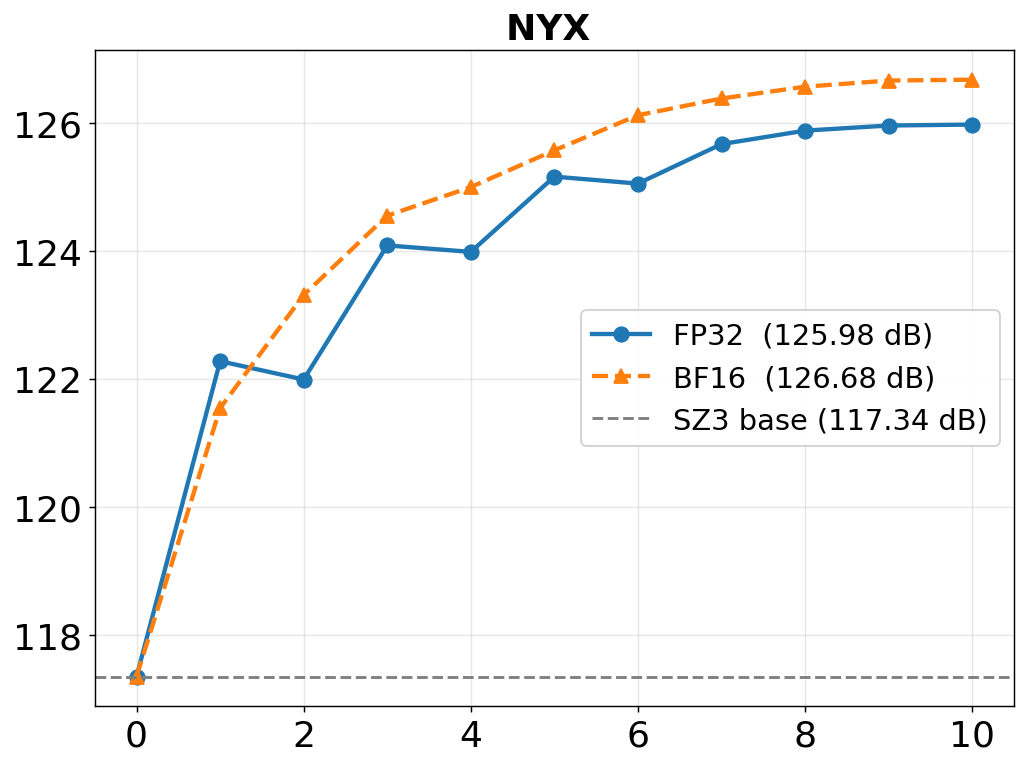

Saved: bf16_vs_fp32_nyx.pdf


In [3]:
# ── NYX (baryon_density), rel=5e-6, ~30k params ──────────────────────────────
NYX_DIR   = "/home/sam/Halo_Finder/halo_finder_v1/SDRBENCH-EXASKY-NYX-512x512x512/origin/"
NYX_SHAPE = (512, 512, 512)
NYX_ALL   = ["baryon_density", "dark_matter_density", "temperature",
             "velocity_x", "velocity_y", "velocity_z"]
NYX_TGT   = "baryon_density"
tgt = np.fromfile(NYX_DIR + NYX_TGT + ".f32", dtype=np.float32).reshape(NYX_SHAPE)
aux = [np.memmap(NYX_DIR + a + ".f32", dtype=np.float32, mode="r", shape=NYX_SHAPE)
       for a in NYX_ALL if a != NYX_TGT]
r_nyx = run_ab("NYX", tgt, aux, rel=5e-6, params=30000, epochs=10)
del tgt, aux
torch.cuda.empty_cache() if torch.cuda.is_available() else None

fig, ax = plt.subplots(figsize=(8, 6), dpi=130)
plot_ab(ax, r_nyx); plt.tight_layout()
plt.savefig("bf16_vs_fp32_nyx.pdf", bbox_inches="tight"); plt.show()
print("Saved: bf16_vs_fp32_nyx.pdf")


[Model: spatial] Total Params: 724
 [Params] Main (BG) Network : 724 parameters

[Model: spatial] Total Params: 1,216
 [Params] Main (BG) Network : 1,216 parameters

[Model: spatial] Total Params: 1,834
 [Params] Main (BG) Network : 1,834 parameters

[Model: spatial] Total Params: 2,578
 [Params] Main (BG) Network : 2,578 parameters

[Model: spatial] Total Params: 3,448
 [Params] Main (BG) Network : 3,448 parameters

[Model: spatial] Total Params: 4,444
 [Params] Main (BG) Network : 4,444 parameters

[Model: spatial] Total Params: 5,566
 [Params] Main (BG) Network : 5,566 parameters

[Model: spatial] Total Params: 6,814
 [Params] Main (BG) Network : 6,814 parameters

[Model: spatial] Total Params: 8,188
 [Params] Main (BG) Network : 8,188 parameters

[Model: spatial] Total Params: 9,688
 [Params] Main (BG) Network : 9,688 parameters

[Model: spatial] Total Params: 11,314
 [Params] Main (BG) Network : 11,314 parameters

[Model: spatial] Total Params: 13,066
 [Params] Main (BG) Network 

/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:522: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):


Epoch   1 [BG] | train_wall=0.66s | Loss: 1.046999 | Freq: 1.655701 | Low: 0.241780 | Mid: 0.085677 | High: 0.193082 | Global: 46.87 dB | MaxErr: 0.0  [New Best!]
[timing] first_epoch_pure_train≈0.731s (excludes this epoch's end-of-epoch eval)
Epoch   2 [BG] | train_wall=0.56s | Loss: 2.045700 | Freq: 1.280145 | Low: 0.242771 | Mid: 0.077253 | High: 0.103027 | Global: 47.56 dB | MaxErr: 0.0  [New Best!]
Epoch   3 [BG] | train_wall=0.60s | Loss: 1.769182 | Freq: 1.136937 | Low: 0.236952 | Mid: 0.066511 | High: 0.065611 | Global: 47.92 dB | MaxErr: 0.0  [New Best!]
Epoch   4 [BG] | train_wall=0.63s | Loss: 1.635818 | Freq: 1.038704 | Low: 0.240543 | Mid: 0.062615 | High: 0.051692 | Global: 48.28 dB | MaxErr: 0.0  [New Best!]
Epoch   5 [BG] | train_wall=0.59s | Loss: 1.740797 | Freq: 1.181831 | Low: 0.236325 | Mid: 0.055901 | High: 0.045315 | Global: 48.28 dB | MaxErr: 0.0
Epoch   6 [BG] | train_wall=0.56s | Loss: 1.793727 | Freq: 1.242591 | Low: 0.229227 | Mid: 0.057323 | High: 0.039950 

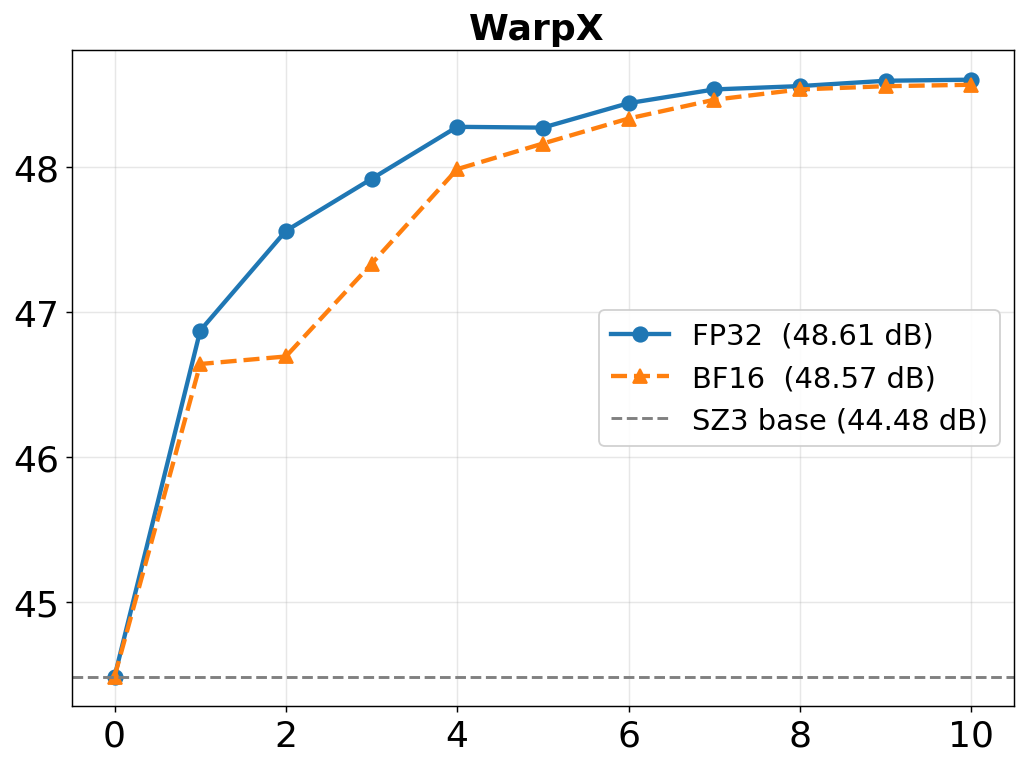

Saved: bf16_vs_fp32_warpx.pdf


In [4]:
# ── WarpX (wpx) -> (2048,256,256), normalized, rel=3e-2 (heavier; fewer epochs) ─
WPX_RAW = "/home/sam/Halo_Finder/halo_finder_v1/wpx-256_256_2048_double.raw"
_v = np.fromfile(WPX_RAW, dtype=np.float64).reshape(256, 256, 2048)
_v = np.ascontiguousarray(np.transpose(_v, (0, 2, 1)))
_v = (_v / (np.abs(_v).max() or 1.0)).astype(np.float32)
r_wpx = run_ab("WarpX", _v, [], rel=3e-2, params=30000, epochs=10)
del _v
torch.cuda.empty_cache() if torch.cuda.is_available() else None

fig, ax = plt.subplots(figsize=(8, 6), dpi=130)
plot_ab(ax, r_wpx); plt.tight_layout()
plt.savefig("bf16_vs_fp32_warpx.pdf", bbox_inches="tight"); plt.show()
print("Saved: bf16_vs_fp32_warpx.pdf")

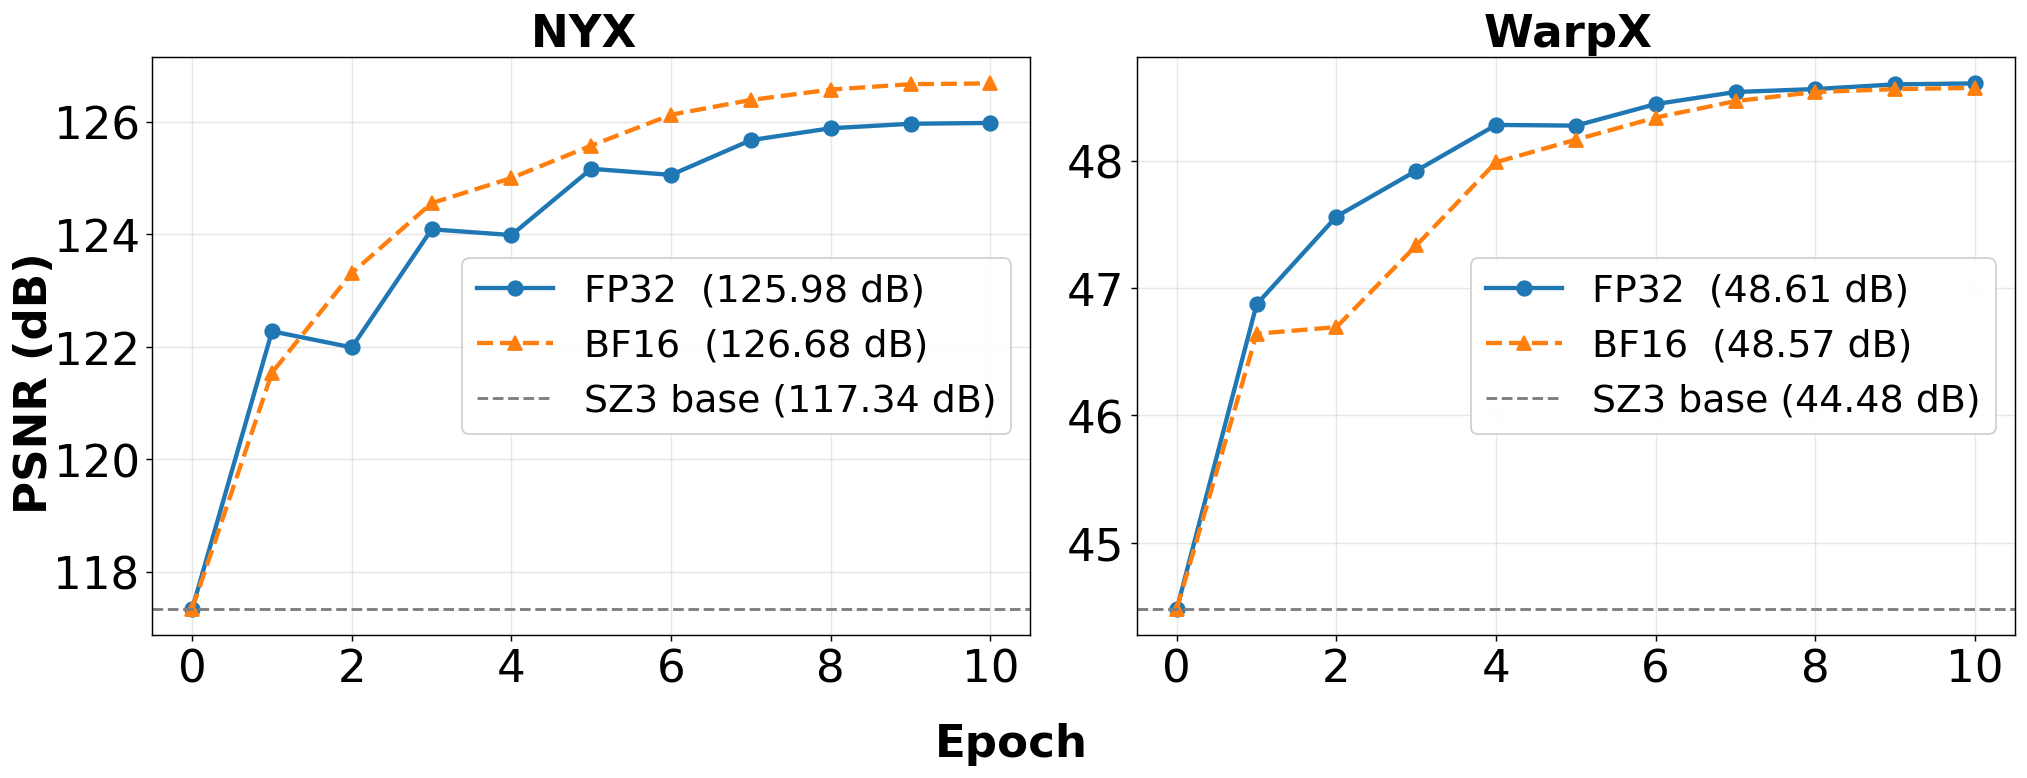

Saved: bf16_vs_fp32_1x2.pdf


In [5]:
# ── Combined 1x2 figure (run the NYX and WarpX cells above first) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=130)
plot_ab(axes[0], r_nyx, fontsize = 25)
plot_ab(axes[1], r_wpx, fontsize = 25)
# fig.suptitle("FP32 vs BF16 training  (same seed / params / epochs; only precision differs)",
#              fontsize=15, fontweight="bold", y=1.02)
fig.supxlabel("Epoch", fontsize=25, fontweight="bold")
fig.supylabel("PSNR (dB)", fontsize=25, fontweight="bold")
plt.tight_layout()
plt.savefig("bf16_vs_fp32_1x2.pdf", bbox_inches="tight"); plt.show()
print("Saved: bf16_vs_fp32_1x2.pdf")